### Final Analysis
Now that we have the serialized model, and the cleaned data, it's time to evaluate our model's performance. For this, we will use the ROC and PR curves, as well as their corresponding AUC scores.

In [1]:
# First, lets import the necessary libraries and make sure that we have all of the objects that we need set up.
from src.model import load_model
from src.data_prep import prep_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

# Load the fitted dummy and weighted models.
model = load_model('model')
dummy = load_model('dummy')
# Load the cleaned dataset and prep it, same as we did in main.py
cleaned = pd.read_csv('outputs/cleaned_data.csv')
X, y, con_cols, cat_cols = prep_data(cleaned, target='Heart Disease Status')
# Copy data splits from main.py so that we can test the same testing set that was created in main.py
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


/Users/garrettbell/Documents/Projects/D502 - Capstone/model_and_analysis/heart_disease_prediction/src/data_prep.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'Yes': 1, 'No': 0})


### ROC-AUC Plot

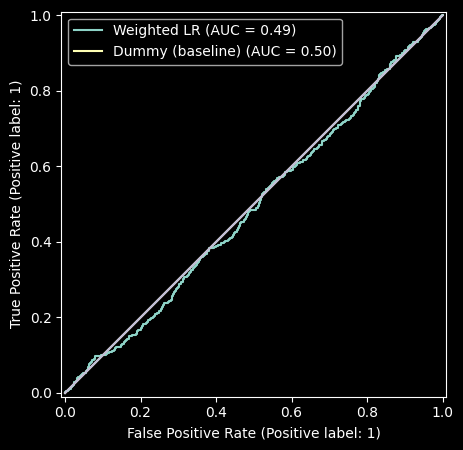

In [2]:
# We'll go ahead and create the plt axis object, since we want to overlay
fig, ax = plt.subplots(figsize=(5,5))
# Now we plot the ROC curves for both of the dummy and the weighted model.
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name="Weighted LR")
RocCurveDisplay.from_estimator(dummy, X_test,y_test, ax=ax, name='Dummy (baseline)')
plt.plot([0,1], [0,1])
plt.legend()

### PR-AUC Plot

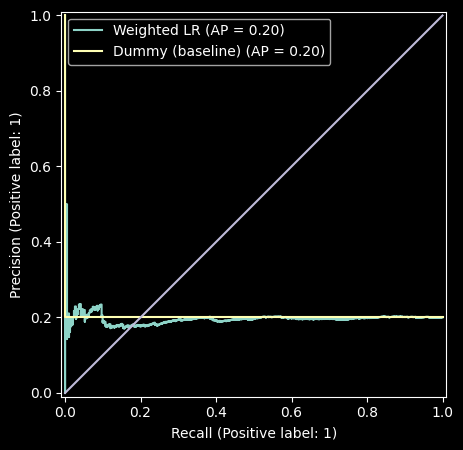

In [3]:
# Now do the same thing that we did for the ROC plot, except do it for the PR-AUC plot
fig, ax = plt.subplots(figsize=(5,5))
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name='Weighted LR')
PrecisionRecallDisplay.from_estimator(dummy, X_test, y_test, ax=ax, name='Dummy (baseline)')
plt.plot([0,1], [0,1])
plt.legend()